# Benchmark: DLTS-DFS vs Greedy (ModelSolver)

Compara el solver greedy baseline contra DLTS-DFS (Algorithm 1, Hottung et al. 2020)
sobre el benchmark CVS estándar.

**Estrategia de imports**: se cargan primero los módulos de main src (CPMPTransformer,
ModelSolver, DLTSDFSSolver), luego se limpia `sys.modules['generation']` para poder
importar los adapters de Repo_Oscar sin conflicto.

In [1]:
import sys, os, json, copy, time
import torch
import numpy as np

MAIN_SRC = os.path.abspath('../src')
REPO_SRC = os.path.abspath('../Repo_Oscar/CPMP-Framework/src')
MODEL_DIR = os.path.abspath('../models')

# ── Fase 1: main src ─────────────────────────────────────────────────────────
sys.path.insert(0, MAIN_SRC)

from training.training import load_model
from models.cpmp_transformer_v9 import CPMPTransformer
from solvers.model import ModelSolver
from solvers.dlts_dfs import DLTSDFSSolver
from cpmp.layout import read_file
from settings import INSTANCE_FOLDER

print('Main src imports OK')

# ── Fase 2: limpiar generation y cargar Repo_Oscar ───────────────────────────
# generation.adapters es un archivo en main src pero un paquete en Repo_Oscar;
# hay que limpiar el cache antes de importar los adapters del bounding model.
gen_cache = {k: v for k, v in sys.modules.items()
             if k == 'generation' or k.startswith('generation.')}
for k in gen_cache:
    del sys.modules[k]

sys.path.insert(0, REPO_SRC)

from models.cost.cost_predictor_V2 import CostPredictorTransformer
from generation.adapters.input.enriched_layout_adapter import EnrichedLayoutAdapter
from generation.adapters.input.layout.layout_4D_adapter_V2 import Layout4DAdapterV2
from generation.adapters.input.stack_features.stack_features_adapter_V1 import StackFeaturesAdapterV1

print('Repo_Oscar imports OK')
print('Todo listo.')

Main src imports OK
Repo_Oscar imports OK
Todo listo.


In [2]:
# ── Cargar modelos ────────────────────────────────────────────────────────────
branching_model = load_model(CPMPTransformer, 'v9_dataBSG_250k')
branching_model.eval()
print(f'Branching model cargado: v9_dataBSG_250k  H={branching_model.hyperparams["H"]}')

def load_bounding_model(name):
    hp = json.load(open(os.path.join(MODEL_DIR, 'hyperparameters', f'{name}.json')))
    model = CostPredictorTransformer(**hp)
    model.load_state_dict(torch.load(os.path.join(MODEL_DIR, f'{name}.pth'),
                                     weights_only=True, map_location='cpu'))
    model.eval()
    return model

bounding_model = load_bounding_model('v2_cost')
print(f'Bounding model cargado: v2_cost')

bounding_adapter = EnrichedLayoutAdapter(
    layout_adapter=Layout4DAdapterV2,
    stack_features_adapter=StackFeaturesAdapterV1,
    S_max=10, H_max=12
)
print(f'Adapter instanciado.')

Branching model cargado: v9_dataBSG_250k  H=12
Bounding model cargado: v2_cost
Adapter instanciado.


In [3]:
# ── Instanciar solvers ────────────────────────────────────────────────────────
greedy_solver = ModelSolver(branching_model)

dlts_solver = DLTSDFSSolver(
    branching_model=branching_model,
    bounding_model=bounding_model,
    bounding_adapter=bounding_adapter,
    p=0.3,          # branch pruning moderado
    k=3,            # recalcular bound cada 3 niveles
    d=0.8,          # bound ligeramente conservador (modelo sobreestima un poco)
    time_limit=15.0 # 15 segundos por instancia
)

print('Solvers listos.')
print(f'  Greedy : ModelSolver')
print(f'  DLTS   : p={dlts_solver.p}, k={dlts_solver.k}, d={dlts_solver.d}, time_limit={dlts_solver.time_limit}s')

Solvers listos.
  Greedy : ModelSolver
  DLTS   : p=0.3, k=3, d=0.8, time_limit=15.0s


In [4]:
# ── Utilidades ────────────────────────────────────────────────────────────────
def avg_steps(solved, steps):
    s = [t for ok, t in zip(solved, steps) if ok]
    return sum(s) / len(s) if s else float('nan')

def avg_time(solved, times):
    t = [t for ok, t in zip(solved, times) if ok]
    return sum(t) / len(t) if t else float('nan')

def run_solver(solver, files, H_inf, max_steps, use_time=False):
    solved_list, steps_list, time_list = [], [], []
    for path in files:
        layout = read_file(path, H_inf)
        t0 = time.perf_counter()
        try:
            result = solver.solve_from_layout(layout, H_inf, max_steps)
            solved, steps = result[0], result[1]
        except Exception:
            solved, steps = False, max_steps
        elapsed = time.perf_counter() - t0
        solved_list.append(solved)
        steps_list.append(steps)
        time_list.append(elapsed)
    return solved_list, steps_list, time_list

print('Utilidades definidas.')

Utilidades definidas.


## Benchmark rápido — instancias pequeñas (3-x, 4-x)

Primero corremos solo las categorías pequeñas para verificar que todo funciona
y tener una idea del rendimiento antes del benchmark completo.

In [5]:
CVS_PATH = INSTANCE_FOLDER / 'benchmarks' / 'CVS'
MAX_STEPS = 100
QUICK_CATS = ['3-3', '3-4', '3-5', '4-4', '4-5']
N_PER_CAT  = 20  # instancias por categoría

SEP = '-' * 105
print(f"{'Cat':>6} {'H':>3} {'S':>3}  "
      f"{'Greedy resuelto':>16} {'avg pasos':>9} {'avg t(s)':>8}  "
      f"{'DLTS resuelto':>14} {'avg pasos':>9} {'avg t(s)':>8}  {'mejor DLTS':>10}")
print(SEP)

results = {}
for folder_name in QUICK_CATS:
    H_r, S_r = [int(x) for x in folder_name.split('-')]
    H_inf = H_r + 2
    folder_path = CVS_PATH / folder_name

    files = sorted([str(folder_path / f)
                    for f in os.listdir(folder_path) if f.endswith('.dat')])[:N_PER_CAT]
    if not files:
        continue

    s_g, st_g, t_g = run_solver(greedy_solver, files, H_inf, MAX_STEPS)
    s_d, st_d, t_d = run_solver(dlts_solver,   files, H_inf, MAX_STEPS)

    # Cuántas instancias mejora DLTS respecto al greedy
    mejor_dlts = sum(
        1 for ok_d, ok_g, sp_d, sp_g in zip(s_d, s_g, st_d, st_g)
        if ok_d and ok_g and sp_d < sp_g
    )

    results[folder_name] = dict(s_g=s_g, st_g=st_g, t_g=t_g,
                                s_d=s_d, st_d=st_d, t_d=t_d)

    ng, nd, n = sum(s_g), sum(s_d), len(files)
    ag = avg_steps(s_g, st_g); tg = avg_time(s_g, t_g)
    ad = avg_steps(s_d, st_d); td = avg_time(s_d, t_d)

    print(f"{folder_name:>6} {H_r:>3} {S_r:>3}  "
          f"{ng:>3}/{n:<3} ({ng/n:>5.1%}) {ag:>9.1f} {tg:>8.3f}  "
          f"{nd:>3}/{n:<3} ({nd/n:>5.1%}) {ad:>9.1f} {td:>8.2f}  {mejor_dlts:>10}")

print(SEP)

   Cat   H   S   Greedy resuelto avg pasos avg t(s)   DLTS resuelto avg pasos avg t(s)  mejor DLTS
---------------------------------------------------------------------------------------------------------


/mnt/data/Proyectos/Universidad/CPMP-Transformer/.venv/lib/python3.14/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


   3-3   3   3   20/20  (100.0%)      11.8    0.017   20/20  (100.0%)      10.7     0.06          12
   3-4   3   4   20/20  (100.0%)      10.2    0.013   20/20  (100.0%)       9.3     0.08          11
   3-5   3   5   20/20  (100.0%)      13.4    0.017   20/20  (100.0%)      11.0     0.33          13
   4-4   4   4   20/20  (100.0%)      20.8    0.026   20/20  (100.0%)      17.4     0.51          12
   4-5   4   5   20/20  (100.0%)      20.6    0.028   20/20  (100.0%)      18.8     2.10          16
---------------------------------------------------------------------------------------------------------


## Benchmark completo — todas las categorías CVS

In [6]:
ALL_CATS = sorted([d for d in os.listdir(CVS_PATH) if (CVS_PATH / d).is_dir()])
N_PER_CAT_FULL = 20

print(f"{'Cat':>6} {'H':>3} {'S':>3}  "
      f"{'Greedy resuelto':>16} {'avg pasos':>9} {'avg t(s)':>8}  "
      f"{'DLTS resuelto':>14} {'avg pasos':>9} {'avg t(s)':>8}  {'mejor DLTS':>10}")
print(SEP)

all_results = {**results}  # incluye los ya calculados

for folder_name in ALL_CATS:
    if folder_name in all_results:
        # ya calculado en el benchmark rápido, solo imprimimos
        r = all_results[folder_name]
        s_g, st_g, t_g = r['s_g'], r['st_g'], r['t_g']
        s_d, st_d, t_d = r['s_d'], r['st_d'], r['t_d']
    else:
        H_r, S_r = [int(x) for x in folder_name.split('-')]
        H_inf = H_r + 2
        folder_path = CVS_PATH / folder_name
        files = sorted([str(folder_path / f)
                        for f in os.listdir(folder_path) if f.endswith('.dat')])[:N_PER_CAT_FULL]
        if not files:
            continue
        s_g, st_g, t_g = run_solver(greedy_solver, files, H_inf, MAX_STEPS)
        s_d, st_d, t_d = run_solver(dlts_solver,   files, H_inf, MAX_STEPS)
        all_results[folder_name] = dict(s_g=s_g, st_g=st_g, t_g=t_g,
                                        s_d=s_d, st_d=st_d, t_d=t_d)

    H_r, S_r = [int(x) for x in folder_name.split('-')]
    mejor_dlts = sum(1 for ok_d, ok_g, sp_d, sp_g in zip(s_d, s_g, st_d, st_g)
                     if ok_d and ok_g and sp_d < sp_g)
    ng, nd, n = sum(s_g), sum(s_d), len(s_g)
    ag = avg_steps(s_g, st_g); tg = avg_time(s_g, t_g)
    ad = avg_steps(s_d, st_d); td = avg_time(s_d, t_d)

    print(f"{folder_name:>6} {H_r:>3} {S_r:>3}  "
          f"{ng:>3}/{n:<3} ({ng/n:>5.1%}) {ag:>9.1f} {tg:>8.3f}  "
          f"{nd:>3}/{n:<3} ({nd/n:>5.1%}) {ad:>9.1f} {td:>8.2f}  {mejor_dlts:>10}")

print(SEP)

# Totales
all_sg  = [s for r in all_results.values() for s in r['s_g']]
all_stg = [s for r in all_results.values() for s in r['st_g']]
all_tg  = [s for r in all_results.values() for s in r['t_g']]
all_sd  = [s for r in all_results.values() for s in r['s_d']]
all_std = [s for r in all_results.values() for s in r['st_d']]
all_td  = [s for r in all_results.values() for s in r['t_d']]

ng_tot, nd_tot, n_tot = sum(all_sg), sum(all_sd), len(all_sg)
print(f"{'TOTAL':>6} {'':>3} {'':>3}  "
      f"{ng_tot:>3}/{n_tot:<3} ({ng_tot/n_tot:>5.1%}) {avg_steps(all_sg, all_stg):>9.1f} {avg_time(all_sg, all_tg):>8.3f}  "
      f"{nd_tot:>3}/{n_tot:<3} ({nd_tot/n_tot:>5.1%}) {avg_steps(all_sd, all_std):>9.1f} {avg_time(all_sd, all_td):>8.2f}")

   Cat   H   S   Greedy resuelto avg pasos avg t(s)   DLTS resuelto avg pasos avg t(s)  mejor DLTS
---------------------------------------------------------------------------------------------------------
 10-10  10  10    0/20  ( 0.0%)       nan      nan    0/20  ( 0.0%)       nan      nan           0
  10-6  10   6    0/20  ( 0.0%)       nan      nan    0/20  ( 0.0%)       nan      nan           0
   3-3   3   3   20/20  (100.0%)      11.8    0.017   20/20  (100.0%)      10.7     0.06          12
   3-4   3   4   20/20  (100.0%)      10.2    0.013   20/20  (100.0%)       9.3     0.08          11
   3-5   3   5   20/20  (100.0%)      13.4    0.017   20/20  (100.0%)      11.0     0.33          13
   3-6   3   6   20/20  (100.0%)      14.3    0.019   20/20  (100.0%)      12.6     2.31          16
   3-7   3   7   20/20  (100.0%)      16.1    0.022   20/20  (100.0%)      13.8     5.62          19
   3-8   3   8   20/20  (100.0%)      16.8    0.023   20/20  (100.0%)      14.6    10.63    

## Análisis de mejora DLTS vs Greedy

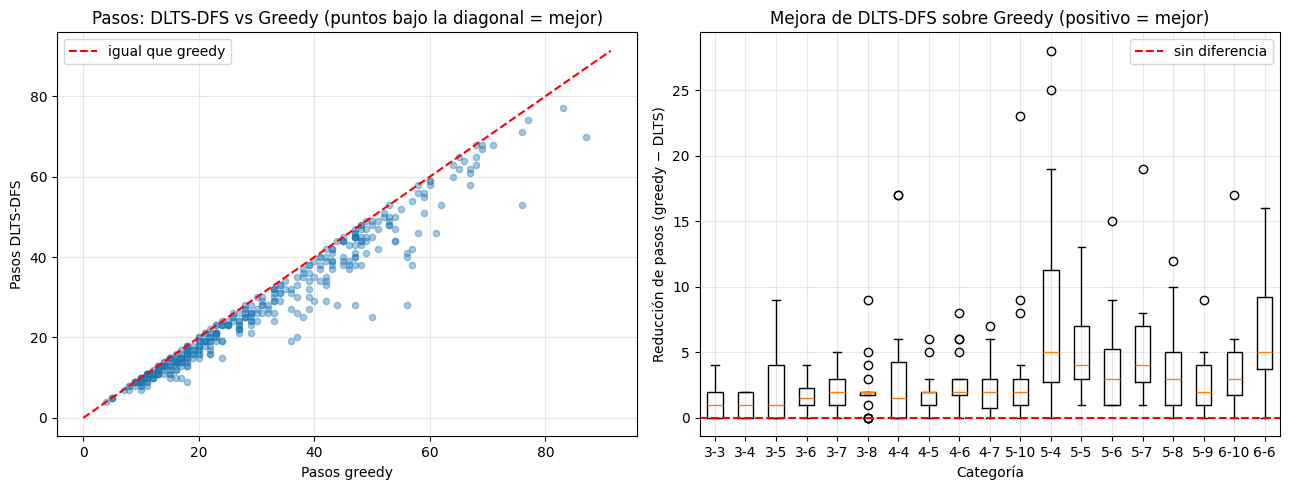

Instancias donde ambos resolvieron: 380
  DLTS mejor que greedy :  316 (83.2%)
  Igual resultado        :   64 (16.8%)
  DLTS peor que greedy  :    0 ( 0.0%)
  Reducción promedio cuando mejora: 4.01 pasos


In [7]:
import matplotlib.pyplot as plt

# ── Comparación de pasos: scatter greedy vs DLTS ─────────────────────────────
steps_g_all, steps_d_all, cats_all = [], [], []
for cat, r in all_results.items():
    for ok_g, ok_d, sp_g, sp_d in zip(r['s_g'], r['s_d'], r['st_g'], r['st_d']):
        if ok_g and ok_d:
            steps_g_all.append(sp_g)
            steps_d_all.append(sp_d)
            cats_all.append(cat)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter pasos
ax = axes[0]
ax.scatter(steps_g_all, steps_d_all, alpha=0.4, s=20)
mx = max(max(steps_g_all), max(steps_d_all)) * 1.05
ax.plot([0, mx], [0, mx], 'r--', lw=1.5, label='igual que greedy')
ax.set_xlabel('Pasos greedy')
ax.set_ylabel('Pasos DLTS-DFS')
ax.set_title('Pasos: DLTS-DFS vs Greedy (puntos bajo la diagonal = mejor)')
ax.legend(); ax.grid(True, alpha=0.3)

# Diferencia de pasos por categoría
ax2 = axes[1]
cat_diffs = {}
for cat, r in all_results.items():
    diffs = [sp_g - sp_d for ok_g, ok_d, sp_g, sp_d
             in zip(r['s_g'], r['s_d'], r['st_g'], r['st_d']) if ok_g and ok_d]
    if diffs:
        cat_diffs[cat] = diffs

sorted_cats = sorted(cat_diffs.keys())
ax2.boxplot([cat_diffs[c] for c in sorted_cats], tick_labels=sorted_cats)
ax2.axhline(0, color='r', linestyle='--', lw=1.5, label='sin diferencia')
ax2.set_xlabel('Categoría')
ax2.set_ylabel('Reducción de pasos (greedy − DLTS)')
ax2.set_title('Mejora de DLTS-DFS sobre Greedy (positivo = mejor)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Resumen numérico
total_mejora = sum(1 for g, d in zip(steps_g_all, steps_d_all) if d < g)
total_igual  = sum(1 for g, d in zip(steps_g_all, steps_d_all) if d == g)
total_peor   = sum(1 for g, d in zip(steps_g_all, steps_d_all) if d > g)
n_ambos = len(steps_g_all)

print(f'Instancias donde ambos resolvieron: {n_ambos}')
print(f'  DLTS mejor que greedy : {total_mejora:>4} ({total_mejora/n_ambos:>5.1%})')
print(f'  Igual resultado        : {total_igual:>4} ({total_igual/n_ambos:>5.1%})')
print(f'  DLTS peor que greedy  : {total_peor:>4} ({total_peor/n_ambos:>5.1%})')
if total_mejora > 0:
    reduc = [g - d for g, d in zip(steps_g_all, steps_d_all) if d < g]
    print(f'  Reducción promedio cuando mejora: {np.mean(reduc):.2f} pasos')